## Image loading and standardization example — Task 3.3

In [1]:
import sys
print("Python:", sys.executable)
sys.path.insert(0, r'F:\V_Tech Semesters\MS Thesis\Jupyter_MS\git\visual-brand-audit\src')

Python: F:\V_Tech Semesters\MS Thesis\Jupyter_MS\venv\Python_3120_modgen3d\Scripts\python.exe


In [2]:
from dataclasses import asdict
from tempfile import TemporaryDirectory
from pathlib import Path

from PIL import Image, ImageCms, UnidentifiedImageError, features
from skimage import data
import matplotlib.pyplot as plt
from IPython.display import display

from brandlens.preprocessing.image_io import load_image
from brandlens.preprocessing.standardization import StandardizationSettings, standardize_image

# settings = StandardizationSettings()
settings = StandardizationSettings(
    max_size=(300, 300),
    background=(255, 255, 255),
)

print("Settings:", asdict(settings))

Settings: {'max_size': (300, 300), 'background': (255, 255, 255)}


# 1. Prepare sample images
Source: scikit-image sample data.

Temporary files below exercise the real loader. The extra examples demonstrate grayscale, transparency, orientation, and an already-small image. A valid sRGB profile exercises the ICC path; it does not validate conversion from a different color space.

In [3]:
samples = [
    {"name": "Astronaut", "kind": "photograph", "image": Image.fromarray(data.astronaut())},
    {"name": "Coffee", "kind": "photograph", "image": Image.fromarray(data.coffee())},
    {"name": "Chelsea", "kind": "photograph", "image": Image.fromarray(data.chelsea())},
    {"name": "Camera", "kind": "photograph", "image": Image.fromarray(data.camera())},
    {"name": "Scikit-image logo", "kind": "graphic", "image": Image.fromarray(data.logo())},
]
print("Loaded", len(samples), "original samples.")

small = samples[1]["image"].copy()
small.thumbnail((80, 80))

rotated = samples[1]["image"].copy()
rotated.getexif()[274] = 6
rotated.info["exif"] = rotated.getexif().tobytes()

transparent = Image.new("RGBA", (400, 200), (0, 0, 0, 0))
transparent.paste((20, 100, 200, 255), (30, 30, 180, 170))
transparent.paste((200, 60, 40, 128), (220, 30, 370, 170))

profiled = samples[2]["image"].copy()
profiled.info["icc_profile"] = ImageCms.ImageCmsProfile(
    ImageCms.createProfile("sRGB")
).tobytes()

samples.extend([
    {"name": "Small photo (no upscaling)", "image": small},
    {"name": "Coffee with EXIF rotation", "image": rotated},
    {"name": "Transparency example", "image": transparent},
    {"name": "Photo with sRGB profile", "image": profiled},
])
print("Prepared", len(samples), "samples.")

Loaded 5 original samples.
Prepared 9 samples.


### 2. Load files and standardize
Images are saved as temporary PNGs, loaded through load_image(), and processed. Temporary files are removed automatically; loaded images remain usable in memory. This cell does not save or overwrite your original files.

In [4]:
results = []
with TemporaryDirectory() as temp_dir:
    for index, sample in enumerate(samples):
        path = Path(temp_dir) / f"sample_{index}.png"
        source = sample["image"]
        save_options = {}
        for key in ("exif", "icc_profile"):
            if key in source.info:
                save_options[key] = source.info[key]
        source.save(path, format="PNG", **save_options)

        original = load_image(path)
        original_pixels = original.tobytes()
        processed = standardize_image(original, settings)

        assert processed is not original
        assert original.tobytes() == original_pixels
        assert processed.mode == "RGB"

        results.append({
            "name": sample["name"],
            "original": original,
            "processed": processed,
        })

print(f"{'Image':<32} {'Original':<21} {'Processed':<21} ICC")
for row in results:
    original, processed = row["original"], row["processed"]
    before = f"{original.size} {original.mode}"
    after = f"{processed.size} {processed.mode}"
    print(f"{row['name']:<32} {before:<21} {after:<21} "
          f"{'icc_profile' in processed.info}")


Image                            Original              Processed             ICC
Astronaut                        (512, 512) RGB        (300, 300) RGB        True
Coffee                           (600, 400) RGB        (300, 200) RGB        True
Chelsea                          (451, 300) RGB        (300, 200) RGB        True
Camera                           (512, 512) L          (300, 300) RGB        True
Scikit-image logo                (500, 500) RGBA       (300, 300) RGB        True
Small photo (no upscaling)       (80, 53) RGB          (80, 53) RGB          True
Coffee with EXIF rotation        (600, 400) RGB        (200, 300) RGB        True
Transparency example             (400, 200) RGBA       (300, 150) RGB        True
Photo with sRGB profile          (451, 300) RGB        (300, 200) RGB        True


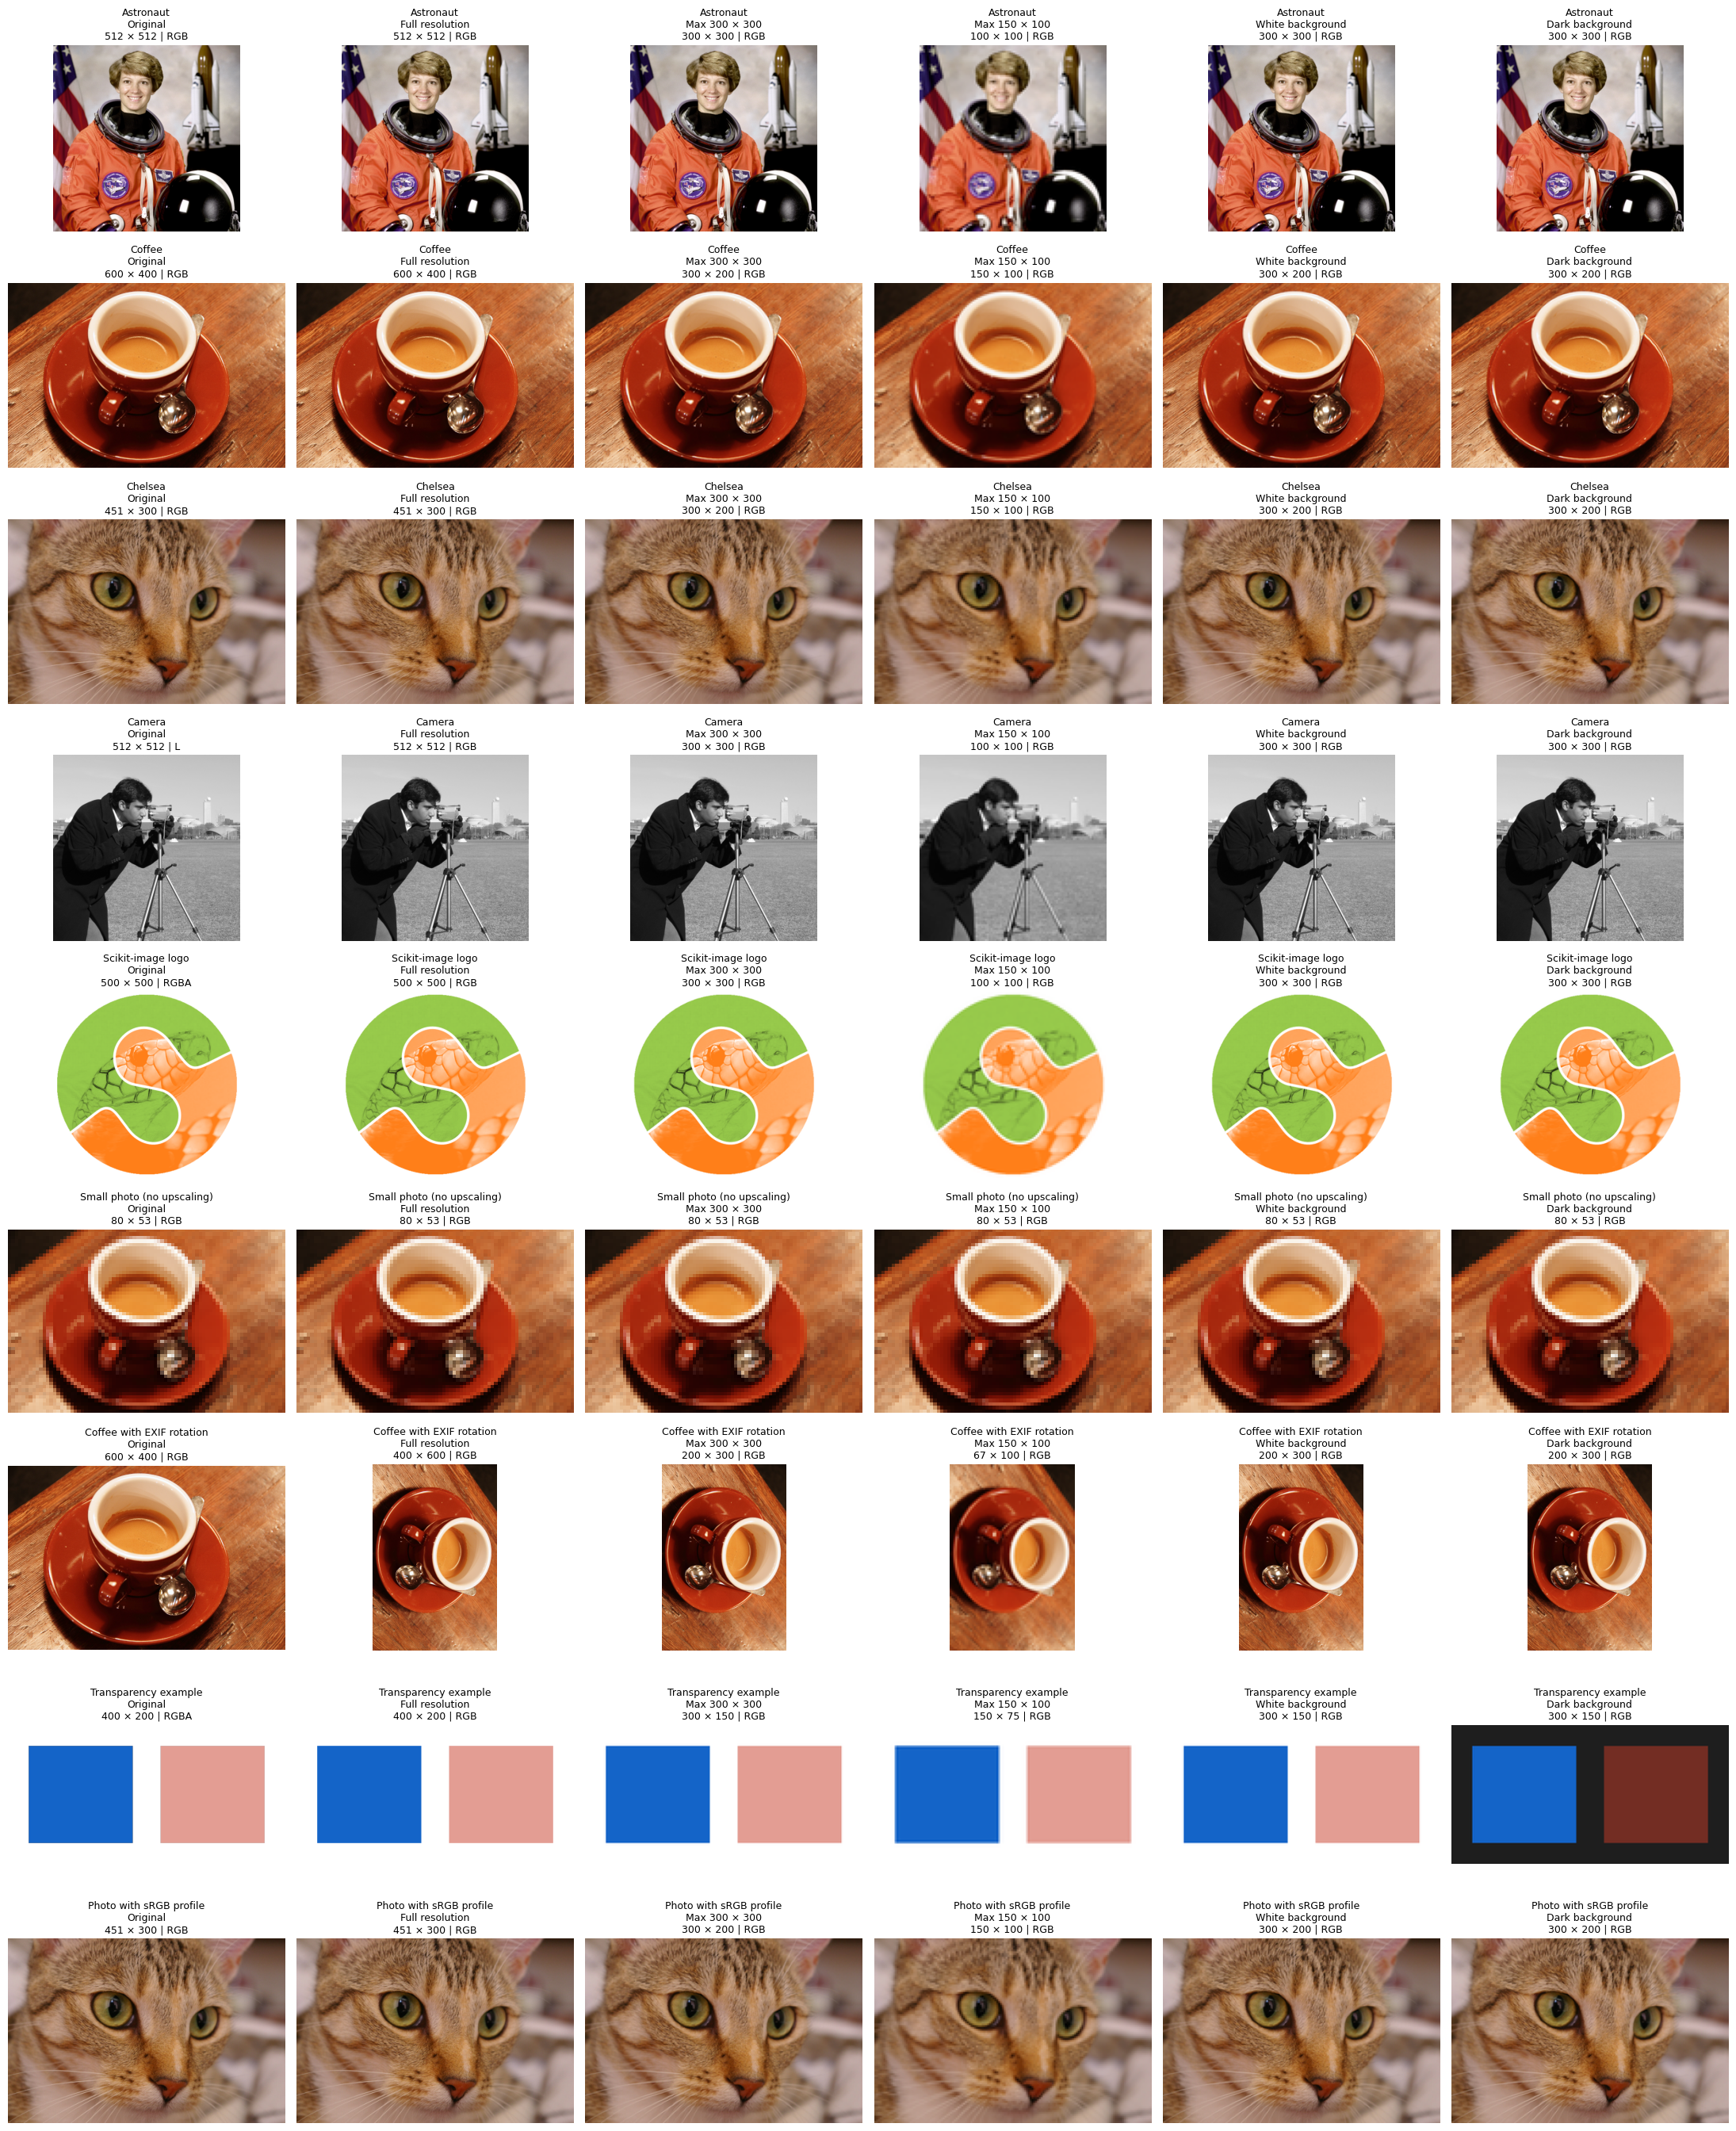

In [5]:
variants = [
    ("Original", None),
    ("Full resolution", StandardizationSettings()),
    ("Max 300 × 300", StandardizationSettings(max_size=(300, 300))),
    ("Max 150 × 100", StandardizationSettings(max_size=(150, 100))),
    (
        "White background",
        StandardizationSettings(
            max_size=(300, 300),
            background=(255, 255, 255),
        ),
    ),
    (
        "Dark background",
        StandardizationSettings(
            max_size=(300, 300),
            background=(30, 30, 30),
        ),
    ),
]

fig, axes = plt.subplots(
    len(samples),
    len(variants),
    figsize=(22, 3 * len(samples)),
    squeeze=False,
)

for row_index, sample in enumerate(samples):
    original = sample["image"]

    for column_index, (label, variant_settings) in enumerate(variants):
        ax = axes[row_index, column_index]

        if variant_settings is None:
            output = original
        else:
            output = standardize_image(original, variant_settings)

        ax.imshow(output.convert("RGBA"))
        ax.set_title(
            f"{sample['name']}\n"
            f"{label}\n"
            f"{output.width} × {output.height} | {output.mode}",
            fontsize=9,
        )
        ax.axis("off")

plt.tight_layout()
plt.show()

### Supported formats and expected errors

JPEG and WebP encoding can change pixel values; this section checks loading support, not pixel equality. WebP is skipped if unavailable in the installed Pillow build. Expected rejection examples are caught and printed.

In [6]:
with TemporaryDirectory() as temp_dir:
    folder = Path(temp_dir)
    for format_name, extension in (("JPEG", "jpg"), ("PNG", "png"), ("WEBP", "webp")):
        if format_name == "WEBP" and not features.check("webp"):
            print("WEBP: unavailable in this Pillow build")
            continue
        path = folder / f"photo.{extension}"
        samples[1]["image"].save(path, format=format_name)
        with load_image(path) as loaded:
            print(format_name, "loaded:", loaded.size, loaded.mode)

    bmp_path = folder / "unsupported.bmp"
    samples[1]["image"].save(bmp_path)
    try:
        load_image(bmp_path)
    except UnidentifiedImageError:
        print("Expected rejection: BMP is outside the default format allowlist.")

    png_path = folder / "photo.png"
    try:
        load_image(png_path, max_pixels=100)
    except ValueError as error:
        print("Expected rejection:", error)


JPEG loaded: (600, 400) RGB
PNG loaded: (600, 400) RGB
WEBP loaded: (600, 400) RGB
Expected rejection: BMP is outside the default format allowlist.
Expected rejection: Image exceeds the limit of 100 pixels.


In [7]:
image_path = None  # Example: Path(r"F:\images\example.png")

if image_path is not None:
    try:
        with load_image(image_path) as original:
            with standardize_image(original, settings) as output:
                print("Original:", original.size, original.mode)
                print("Output:", output.size, output.mode)
                display(output)
    except (OSError, ValueError) as error:
        print(type(error).__name__, str(error))
else:
    print("Set image_path to try your own photograph.")


Set image_path to try your own photograph.
